## Задача
Исследовать **структуру спроса и отмен бронирований** в городском и курортном отелях, **выявить факторы, связанные с отменами**, **изучить сезонность, стоимость и длительность проживания**, а также 
**сформировать рекомендации по работе со спросом и отменами бронирований**.

## Исследовательские вопросы

### Спрос

- Как меняется число бронирований по месяцам?
- Отличается ли сезонность городского и курортного отелей?
- Какова средняя длительность проживания?
- В какие месяцы число состоявшихся заездов максимально?
- Какова доля бронирований с признкаом повторного гостя?

### Отмены

- Какая доля бронирований отменяется?
- Где отмен больше: в городском или курортном отеле?
- Как отмены связаны с `lead_time`?
- Отличается ли доля отмен между рыночными сегментами?
- Как тип депозита связан с отменами?

### Стоимость

- Как распределяется `adr`?
- Отличается ли стоимость между отелями?
- Как стоимость меняется по сезонам?
- Зависит ли она от количества гостей и типа номера?
- Есть ли подозрительные значения?

### Клиенты и каналы

- Из каких стран приезжают гости?
- Какие каналы дают больше бронирований?
- Какие каналы связаны с высокой долей отмен?
- Отличаются ли бронирования с признаком повторного гостя по стоимости, длительности проживания и отменам?

## Единицы наблюдения и ограничения
- одна строка соответствует одному бронированию
- кол-во бронирований != кол-во уникальных гостей
- без информации о размере жилого фонда нельзя рассчитать процент загрузки
- число заездов за месяц != числу проживающих каждую ночь

In [1]:
from pathlib import Path
from IPython.display import display

import pandas as pd
import matplotlib.pyplot as plt


In [2]:

# Поддерживаем запуск из корня проекта и из notebooks/.
PROJECT_ROOT = next(
    (path for path in (Path.cwd(), *Path.cwd().parents)
     if (path / "data" / "raw").is_dir()),
    None,
)
if PROJECT_ROOT is None:
    raise FileNotFoundError("Откройте ноутбук из папки проекта Hotel_EDA.")

DATA_DIR = PROJECT_ROOT / "data" / "raw"
DATA_PATH = DATA_DIR / "hotel_bookings.csv"

if not DATA_PATH.exists():
    import kagglehub

    kagglehub.dataset_download(
        "jessemostipak/hotel-booking-demand",
        path="hotel_bookings.csv",
        output_dir=DATA_DIR,
    )

df = pd.read_csv(DATA_PATH)
df.head()


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  str    
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  str    
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal                       

In [4]:
df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


In [5]:
month_map = {
    "January": 1,
    "February": 2,
    "March": 3,
    "April": 4,
    "May": 5,
    "June": 6,
    "July": 7,
    "August": 8,
    "September": 9,
    "October": 10,
    "November": 11,
    "December": 12,
}

In [6]:
df_prepared=df.copy()

In [7]:
df_prepared["arrival_date"] = pd.to_datetime(
      {
          "year": df_prepared["arrival_date_year"],
          "month": df_prepared["arrival_date_month"].map(month_map),
          "day": df_prepared["arrival_date_day_of_month"],
      },
      errors="coerce",
  )

In [8]:
df_prepared['reservation_status_date']=pd.to_datetime(
    df_prepared['reservation_status_date'],
    format='%Y-%m-%d',
    errors='coerce'
)

In [9]:
df_prepared[['arrival_date','reservation_status_date']].head()

,arrival_date,reservation_status_date
0,2015-07-01,2015-07-01
1,2015-07-01,2015-07-01
2,2015-07-01,2015-07-02
3,2015-07-01,2015-07-02
4,2015-07-01,2015-07-03


In [10]:
print(df_prepared['arrival_date'].dtype,df_prepared['reservation_status_date'].dtype)

datetime64[us] datetime64[us]


In [11]:
print(df_prepared['arrival_date'].isna().sum())

0


In [12]:
print(df_prepared['reservation_status_date'].isna().sum())

0


In [13]:
display(df_prepared['arrival_date'].agg(['min','max']))

min   2015-07-01
max   2017-08-31
Name: arrival_date, dtype: datetime64[us]

In [14]:
missing_summary=pd.DataFrame(
    {'missing_count': df_prepared.isna().sum(),
    'missing_pct': df_prepared.isna().mean().mul(100).round(2),
})


In [15]:
missing_summary[missing_summary['missing_count']!=0]

,missing_count,missing_pct
children,4,0.00
country,488,0.41
agent,16340,13.69
company,112593,94.31


In [16]:
missing_chidren=df_prepared.loc[df_prepared['children'].isna(),
    [
      "hotel", "arrival_date", "adults", "children", "babies",
      "market_segment", "distribution_channel",
      "reservation_status", "adr",
  ]
]

In [17]:
missing_chidren

,hotel,arrival_date,adults,children,babies,market_segment,distribution_channel,reservation_status,adr
40600,City Hotel,2015-08-03,2,NaN,0,Undefined,Undefined,Canceled,12.0
40667,City Hotel,2015-08-05,2,NaN,0,Direct,Undefined,Canceled,12.0
40679,City Hotel,2015-08-05,3,NaN,0,Undefined,Undefined,Canceled,18.0
41160,City Hotel,2015-08-13,2,NaN,0,Online TA,Undefined,Canceled,76.5


In [18]:
country_summary=df_prepared.groupby('hotel').agg(
    bookings=('country','size'),
    known_country=('country','count')
)

In [19]:
country_summary.head()

,bookings,known_country
hotel,,
City Hotel,79330,79306
Resort Hotel,40060,39596


In [20]:
country_summary['missing_country']=country_summary['bookings']-country_summary['known_country']

In [21]:
country_summary['missing_country_pct']=country_summary['missing_country'].div(country_summary['bookings']).mul(100).round(2)
country_summary

,bookings,known_country,missing_country,missing_country_pct
hotel,,,,
City Hotel,79330,79306,24,0.03
Resort Hotel,40060,39596,464,1.16


In [22]:
agent_summary=df_prepared.groupby('distribution_channel').agg(
    bookings_size=('agent','size'),
    known_agent=('agent','count'),
    missing_agent=('agent',lambda s: s.isna().sum()),
)

agent_summary['missing_agent_pct']=agent_summary['missing_agent'].div(agent_summary['bookings_size']).mul(100).round(2)

In [23]:
agent_summary

,bookings_size,known_agent,missing_agent,missing_agent_pct
distribution_channel,,,,
Corporate,6677,1134,5543,83.02
Direct,14645,7020,7625,52.07
GDS,193,191,2,1.04
TA/TO,97870,94703,3167,3.24
Undefined,5,2,3,60.00


In [24]:
company_summary=df_prepared.groupby('market_segment').agg(
    bookings=('company','size'),
    known_company=('company','count'),
    missing_company=('company',lambda s: s.isna().sum()),
)

company_summary['missing_company_pct']=company_summary['missing_company'].div(company_summary['bookings']).mul(100).round(2)
company_summary

,bookings,known_company,missing_company,missing_company_pct
market_segment,,,,
Aviation,237,212,25,10.55
Complementary,743,313,430,57.87
Corporate,5295,4471,824,15.56
Direct,12606,208,12398,98.35
Groups,19811,1391,18420,92.98
Offline TA/TO,24219,106,24113,99.56
Online TA,56477,96,56381,99.83
Undefined,2,0,2,100.00


In [25]:
company_summary['missing_company'].sum()

np.int64(112593)

In [26]:
company_summary["bookings"] == company_summary["known_company"] + company_summary["missing_company"]

market_segment
Aviation         True
Complementary    True
Corporate        True
Direct           True
Groups           True
Offline TA/TO    True
Online TA        True
Undefined        True
dtype: bool

### Итоги проверки пропусков

- Пропуски найдены в четырёх полях: `children` — 4, `country` — 488 (0,41%), `agent` — 16 340 (13,69%), `company` — 112 593 (94,31%). Пропуск означает отсутствие значения, а не числовой ноль.
- Во всех четырёх записях без `children` указан City Hotel, статус `Canceled` и канал `Undefined`. Установить число детей по остальным полям нельзя, поэтому неизвестное значение сохраняем.
- Страна неизвестна у 0,03% бронирований City Hotel и 1,16% Resort Hotel. При сравнении географии бронирований учитываем эту разницу; наиболее частой страной пропуски не заполняем.
- Заполненность `agent` и `company` связана с каналом и сегментом, но не определяет их однозначно: `agent` встречается в `Direct`, а `company` — вне `Corporate`. Причины отсутствия идентификаторов требуют уточнения по описанию источника.

На этом этапе строки сохраняем, пропуски не заполняем. Далее проверим полные совпадения строк и оценим их влияние на число бронирований и долю отмен.


In [27]:
print(f'Кол-во повторов {df.duplicated().sum()}')
print(f'Кол-во неуникальных строк {df.duplicated(keep=False).sum()}')
df.loc[df.duplicated(keep=False)].head(10)

Кол-во повторов 31994
Кол-во неуникальных строк 40165


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.00,0,1,Check-Out,2015-07-03
5,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.00,0,1,Check-Out,2015-07-03
21,Resort Hotel,0,72,2015,July,27,1,2,4,2,...,No Deposit,250.0,NaN,0,Transient,84.67,0,1,Check-Out,2015-07-07
22,Resort Hotel,0,72,2015,July,27,1,2,4,2,...,No Deposit,250.0,NaN,0,Transient,84.67,0,1,Check-Out,2015-07-07
39,Resort Hotel,0,70,2015,July,27,2,2,3,2,...,No Deposit,250.0,NaN,0,Transient,137.00,0,1,Check-Out,2015-07-07
43,Resort Hotel,0,70,2015,July,27,2,2,3,2,...,No Deposit,250.0,NaN,0,Transient,137.00,0,1,Check-Out,2015-07-07
132,Resort Hotel,1,5,2015,July,28,5,1,0,2,...,No Deposit,240.0,NaN,0,Transient,97.00,0,0,Canceled,2015-07-01
138,Resort Hotel,1,5,2015,July,28,5,1,0,2,...,No Deposit,240.0,NaN,0,Transient,97.00,0,0,Canceled,2015-07-01
198,Resort Hotel,0,0,2015,July,28,7,0,1,1,...,No Deposit,240.0,NaN,0,Transient,109.80,0,3,Check-Out,2015-07-08
200,Resort Hotel,0,0,2015,July,28,7,0,1,1,...,No Deposit,240.0,NaN,0,Transient,109.80,0,3,Check-Out,2015-07-08


### Размеры групп полностью совпадающих строк

Размер группы включает первое вхождение: группа из трёх строк даёт два повтора после первого вхождения. Сравниваем все исходные столбцы `df`, включая пропуски; строки не удаляем.

`DataFrame.value_counts(dropna=False)` считает частоту каждой комбинации полей. Затем `Series.value_counts()` считает, сколько групп имеет каждый размер. Слева показаны размеры 2–19, выбранные в `frequencies`, справа — полное распределение с логарифмической шкалой Y, позволяющей увидеть редкие крупные группы. Нулевые частоты на логарифмической шкале не отображаются.

In [28]:
row_frequencies=df.value_counts(dropna=False)
duplicate_group_sizes=row_frequencies[row_frequencies>1]

duplicate_distribution=(
    duplicate_group_sizes.value_counts()
    .sort_index()
    .rename_axis("group_size")
    .rename("group_count")
    .to_frame()
)
duplicate_distribution.head()

,group_count
group_size,
2,5034
3,969
4,497
5,275
6,171


In [29]:
frequencies=duplicate_distribution['group_count'].reindex(range(2,20),fill_value=0)

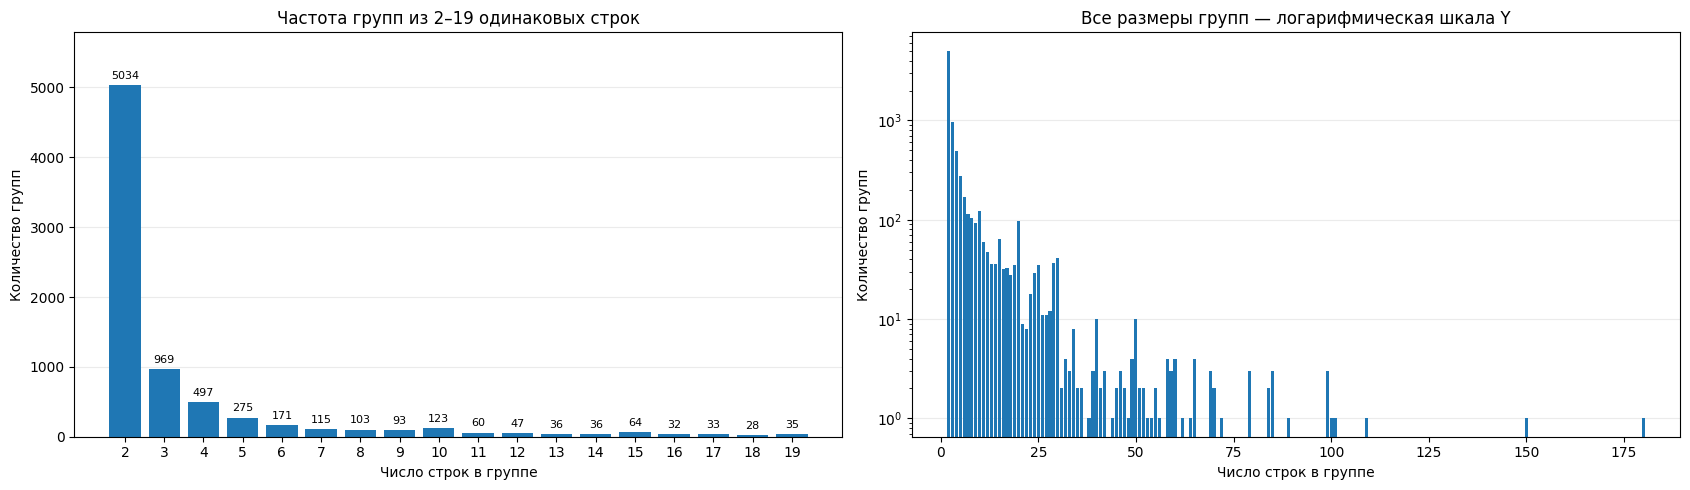

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(17, 5))


bars = axes[0].bar(frequencies.index, height=frequencies.values)
axes[0].bar_label(bars, padding=3, fontsize=8)
axes[0].set_xticks(frequencies.index)
axes[0].set_ylim(0, frequencies.max() * 1.15)
axes[0].set_title(
    f"Частота групп из {frequencies.index.min()}–{frequencies.index.max()} одинаковых строк"
)

# Полное распределение: логарифмическая шкала только по оси Y.
axes[1].bar(
    duplicate_distribution.index,
    height=duplicate_distribution["group_count"],
)
axes[1].set_yscale("log")
axes[1].set_title("Все размеры групп — логарифмическая шкала Y")

for ax in axes:
    ax.set_xlabel("Число строк в группе")
    ax.set_ylabel("Количество групп")
    ax.grid(axis="y", alpha=0.25)
    ax.set_axisbelow(True)

plt.tight_layout()
plt.show()


**Наблюдения:**

- Найдено 8 171 группа полных совпадений, в которых участвуют 40 165 строк. Повторов после первого вхождения — 31 994; оба числа согласуются с проверкой `duplicated()`.
- Чаще всего встречаются пары — 5 034 группы; троек — 969, четвёрок — 497, пятёрок — 275.
- Распределение имеет длинный хвост: максимальная группа содержит 180 одинаковых строк. Есть локальные повышения частоты, например у размеров 10, 20 и 30.
- Размеры групп сами по себе не объясняют происхождение совпадений. Чтобы проверить возможные связи с групповыми бронированиями или особенностями выгрузки, далее стоит изучить отели, сегменты, даты и статусы наиболее крупных групп. До выяснения причин сохраняем исходные строки.

### Проверка возможной связи с групповыми бронированиями

Разные бронирования могут иметь одинаковые сохранённые характеристики, например при оформлении нескольких номеров для туристической группы. Посмотрим, относится ли сегмент десяти крупнейших групп совпадений к `Groups`. Одна строка следующей таблицы представляет группу совпадений, а `group_size` показывает её размер. Наличие `Groups` согласуется с этим объяснением, но не доказывает его; отсутствие также не устанавливает ошибку регистрации.

In [31]:
largest_duplicate_groups = (
    duplicate_group_sizes
    .nlargest(10)
    .reset_index(name="group_size")
)

display(largest_duplicate_groups[["group_size", "hotel", "market_segment"]])


,group_size,hotel,market_segment
0,180,City Hotel,Groups
1,150,City Hotel,Groups
2,109,City Hotel,Offline TA/TO
3,101,City Hotel,Groups
4,100,City Hotel,Offline TA/TO
5,99,City Hotel,Corporate
6,99,City Hotel,Groups
7,99,City Hotel,Groups
8,89,City Hotel,Offline TA/TO
9,85,City Hotel,Offline TA/TO


**Гипотеза:** часть полных совпадений может отражать разные бронирования с одинаковыми характеристиками, оформленные для одной группы. Среди десяти крупнейших групп совпадений пять относятся к `Groups`, четыре — к `Offline TA/TO`, одна — к `Corporate`. Это согласуется с гипотезой, но не исключает ошибочного дублирования; для надёжной проверки нужны исходные ID или история записей.

Совпадающие строки сохраняем. Влияние их условного удаления на число бронирований и долю отмен оценим отдельно.


In [32]:
df_prepared['total_nights']=df_prepared['stays_in_weekend_nights']+df_prepared['stays_in_week_nights']
df_prepared['total_guests']=df_prepared[['adults','children','babies']].sum(min_count=3,axis=1)

df_prepared[['total_nights','total_guests']].describe()

,total_nights,total_guests
count,119390.000000,119386.000000
mean,3.427900,1.968229
std,2.557439,0.722400
min,0.000000,0.000000
25%,2.000000,2.000000
50%,3.000000,2.000000
75%,4.000000,2.000000
max,69.000000,55.000000


In [33]:
display(df_prepared[['stays_in_weekend_nights','stays_in_weekend_nights','total_nights','adults','children','babies','total_guests']].head())
df_prepared[['total_nights','total_guests']].isna().sum()

,stays_in_weekend_nights,stays_in_weekend_nights,total_nights,adults,children,babies,total_guests
0,0,0,0,2,0.0,0,2.0
1,0,0,0,2,0.0,0,2.0
2,0,0,1,1,0.0,0,1.0
3,0,0,1,1,0.0,0,1.0
4,0,0,2,2,0.0,0,2.0


total_nights    0
total_guests    4
dtype: int64

### Даты закрытия бронирований без ночёвок

Проверим, совпадает ли дата статуса с предполагаемой датой заезда у записей с `total_nights = 0` и статусом `Check-Out`. Различия дат считаем диагностическими случаями; строки не удаляем.

In [34]:
zero_night_checkouts = df_prepared.loc[
    (df_prepared["total_nights"] == 0)
    & (df_prepared["reservation_status"] == "Check-Out"),
    ["hotel", "arrival_date", "reservation_status_date", "total_nights", "adr"],
].copy()

# Разница в днях: положительная — статус установлен после даты заезда.
zero_night_checkouts["status_date_gap_days"] = (
    zero_night_checkouts["reservation_status_date"]
    - zero_night_checkouts["arrival_date"]
).dt.days

date_gap = zero_night_checkouts["status_date_gap_days"]
zero_night_date_summary = pd.DataFrame({
    "Количество": [
        (date_gap == 0).sum(),
        (date_gap < 0).sum(),
        (date_gap > 0).sum(),
        date_gap.isna().sum(),
    ],
}, index=["Даты совпадают", "Статус раньше заезда", "Статус позже заезда", "Дата неизвестна"])
zero_night_date_summary["Доля, %"] = (
    zero_night_date_summary["Количество"]
    .div(len(zero_night_checkouts) or float("nan"))
    .mul(100).round(2)
)
print(f"Записей с нулём ночей и статусом Check-Out: {len(zero_night_checkouts)}")
display(zero_night_date_summary)
display(zero_night_checkouts.head(5))

# Если даты различаются или неизвестны, покажем примеры для проверки.
if ((date_gap != 0) | date_gap.isna()).any():
    display(zero_night_checkouts.loc[(date_gap != 0) | date_gap.isna()].head(10))


Записей с нулём ночей и статусом Check-Out: 680


,Количество,"Доля, %"
Даты совпадают,680,100.0
Статус раньше заезда,0,0.0
Статус позже заезда,0,0.0
Дата неизвестна,0,0.0


,hotel,arrival_date,reservation_status_date,total_nights,adr,status_date_gap_days
0,Resort Hotel,2015-07-01,2015-07-01,0,0.0,0
1,Resort Hotel,2015-07-01,2015-07-01,0,0.0,0
167,Resort Hotel,2015-07-06,2015-07-06,0,0.0,0
168,Resort Hotel,2015-07-06,2015-07-06,0,0.0,0
196,Resort Hotel,2015-07-07,2015-07-07,0,0.0,0


**Вывод:** из 680 записей даты совпадают у 680; статус раньше заезда — у 0, позже — у 0. Неизвестных разниц дат — 0.

Совпадение дат согласуется с закрытием бронирования в день предполагаемого заезда, но не позволяет различить пребывание без ночёвки, техническое закрытие и ошибку данных. Статус `Check-Out` сам по себе не подтверждает фактическое проживание. Эти записи сохраняем для дальнейшего разбора.

In [35]:
zero_guest_bookings=df_prepared.loc[df_prepared['total_guests']==0]
print(f'Кол-во строк с total_guests==0: {len(zero_guest_bookings)}, от общего числа строк: {round(len(zero_guest_bookings)/len(df_prepared)*100,2)}%')

Кол-во строк с total_guests==0: 180, от общего числа строк: 0.15%


In [36]:
columns = [
      "hotel", "adults", "children", "babies", "total_guests",
      "total_nights", "reservation_status", "adr",
]
display(zero_guest_bookings[columns].head(10))
display(zero_guest_bookings.groupby('reservation_status').agg(
    bookings=('total_guests','size'),
    zero_nights=('total_nights',lambda s: s.eq(0).sum()),
    zero_adr=('adr',lambda s: s.eq(0).sum())
))

,hotel,adults,children,babies,total_guests,total_nights,reservation_status,adr
2224,Resort Hotel,0,0.0,0,0.0,3,Check-Out,0.0
2409,Resort Hotel,0,0.0,0,0.0,0,Check-Out,0.0
3181,Resort Hotel,0,0.0,0,0.0,3,Check-Out,0.0
3684,Resort Hotel,0,0.0,0,0.0,5,Check-Out,0.0
3708,Resort Hotel,0,0.0,0,0.0,6,Check-Out,0.0
4127,Resort Hotel,0,0.0,0,0.0,0,Canceled,0.0
9376,Resort Hotel,0,0.0,0,0.0,0,Canceled,0.0
31765,Resort Hotel,0,0.0,0,0.0,10,Check-Out,28.0
32029,Resort Hotel,0,0.0,0,0.0,1,Check-Out,0.0
32827,Resort Hotel,0,0.0,0,0.0,12,Check-Out,0.0


,bookings,zero_nights,zero_adr
reservation_status,,,
Canceled,24,12,24
Check-Out,155,58,124
No-Show,1,0,1
